# Task 2 - Feature Engineering Infrastructure (Shaw Team)

Reusable infrastructure for **generating and validating** features for the liquidation-based
trade-filtering task. This notebook is a guided demo of the `shaw_features` package:

1. load a slice of real BTC data through the package loader;
2. build a `MarketContext` (the single Polars boundary: it applies the Bybit **+200 ms** lag,
   sorts the liquidation streams and precomputes prefix sums / BBO series);
3. run the 12 example features into a feature matrix with a `FeatureSet`;
4. **validate** every feature - no NaN, no inf, correct alignment, and no forward-looking data
   (a differential re-computation on data truncated to each trade's timestamp);
5. show that the validator actually *catches* a deliberately look-ahead feature;
6. note the streaming path for the full (multi-hundred-million-row) trades table.

> The focus of the task is the **infrastructure** - feature classes, a generation pipeline and
> validation that guarantees features are clean, aligned and causal - not PnL tuning. Adding a
> feature is one small `BaseFeature` subclass that the pipeline and validators pick up
> automatically.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("."))

# Reviewers: point SHAW_DATA_ROOT at the folder that holds binance_trades/ etc.
DATA_ROOT = os.environ.get("SHAW_DATA_ROOT", "liquidation_task/data")

from datetime import datetime, timezone
import polars as pl
import matplotlib.pyplot as plt

from shaw_features import MarketContext, FeatureSet, default_features, loader
pl.Config.set_tbl_rows(20)
print("data root:", DATA_ROOT)

data root: /Users/mvvm/Documents/REPS/CMF/HFT_SHAW_TEAM/liquidation_task/data


## 1. Load a slice of real data
A 3-hour BTC window keeps the demo fast; liquidation/BBO frames are clipped to the same window.

In [2]:
start = int(datetime(2025, 12, 1, 0, 0, tzinfo=timezone.utc).timestamp() * 1e6)
end   = int(datetime(2025, 12, 1, 3, 0, tzinfo=timezone.utc).timestamp() * 1e6)

frames = loader.load_window("btc", start, end, data_root=DATA_ROOT)
{k: v.height for k, v in frames.items()}

{'trades': 1597837, 'bbo': 188742, 'liq_binance': 784, 'liq_bybit': 3093}

## 2. Build the MarketContext
This is where the Bybit +200 ms shift and all prefix-sum / BBO preparation happen, once.

In [3]:
ctx = MarketContext.from_frames(
    frames["trades"], frames["bbo"], frames["liq_binance"], frames["liq_bybit"]
)
print("trades:", ctx.n_trades)
print("liquidation streams:", {k: len(v.ts) for k, v in ctx.streams.items()})

trades: 1597837
liquidation streams: {'binance': 784, 'bybit': 3093, 'combined': 3877}


## 3. Generate the feature matrix
`default_features()` is a 12-feature example set; `FeatureSet.generate` returns one row per trade.

In [4]:
fs = FeatureSet(default_features())
print("features:", fs.names)
matrix = fs.generate(ctx)
matrix.head(5)

features: ['liq_notional_30s', 'liq_notional_120s', 'liq_notional_300s', 'liq_count_30s', 'liq_side_imbalance_30s', 'liq_velocity_30s_120s', 'binance_liq_notional_30s', 'bybit_liq_notional_30s', 'time_since_liq_s', 'bbo_spread_bps', 'bbo_imbalance', 'mid_return_5s_bps']


timestamp,liq_notional_30s,liq_notional_120s,liq_notional_300s,liq_count_30s,liq_side_imbalance_30s,liq_velocity_30s_120s,binance_liq_notional_30s,bybit_liq_notional_30s,time_since_liq_s,bbo_spread_bps,bbo_imbalance,mid_return_5s_bps
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1764547200047000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000e9,0.0,0.0,0.0
1764547200047000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000e9,0.0,0.0,0.0
1764547200047000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000e9,0.0,0.0,0.0
1764547200047000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000e9,0.0,0.0,0.0
1764547200050000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000e9,0.0,0.0,0.0


In [5]:
matrix.drop('timestamp').describe()

statistic,liq_notional_30s,liq_notional_120s,liq_notional_300s,liq_count_30s,liq_side_imbalance_30s,liq_velocity_30s_120s,binance_liq_notional_30s,bybit_liq_notional_30s,time_since_liq_s,bbo_spread_bps,bbo_imbalance,mid_return_5s_bps
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6,1.597837e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",412520.406432,1.3300e6,2.9832e6,31.259384,-0.389546,0.287923,49646.533728,362873.872705,221594.949848,0.06153,-0.003031,-1.116396
"""std""",975150.340171,1.9415e6,3.3759e6,74.455671,0.700763,0.360037,139207.772802,943873.632153,1.4883e7,0.336377,0.770868,7.702171
"""min""",0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.001,0.0,-0.999913,-90.573711
"""25%""",0.0,28366.3221,179708.4594,0.0,-1.0,0.0,0.0,0.0,1.459,0.011354,-0.844918,-3.399854
"""50%""",11439.8909,287035.4892,1.7924e6,3.0,-0.969199,0.068081,4874.9892,0.0,11.207,0.011443,0.00649,-0.448427
"""75%""",279169.0178,1.9796e6,4.2599e6,24.0,0.0,0.573286,50830.5382,166478.7807,44.575,0.011491,0.833381,2.147948
"""max""",5.9255e6,8.4279e6,1.4013e7,494.0,1.0,1.0,2.4063e6,5.6022e6,1.0000e9,12.595443,0.999955,44.897543


## 4. Validate every feature
`finite` (no NaN/inf), `alignment` (one value per trade) and `no_lookahead` (differential causal check).

In [6]:
report = fs.validate(ctx, n_probe=300)
with pl.Config(tbl_cols=-1, tbl_width_chars=220):
    print(report)
print("\nALL FEATURES VALID:", bool(report["ok"].all()))

shape: (12, 10)
┌──────────────────────────┬────────────┬───────────┬───────┬───────┬─────────┬─────────────────┬──────────────────────┬──────────────┬──────┐
│ feature                  ┆ lookback_s ┆ finite_ok ┆ n_nan ┆ n_inf ┆ aligned ┆ no_lookahead_ok ┆ lookahead_violations ┆ max_abs_diff ┆ ok   │
│ ---                      ┆ ---        ┆ ---       ┆ ---   ┆ ---   ┆ ---     ┆ ---             ┆ ---                  ┆ ---          ┆ ---  │
│ str                      ┆ f64        ┆ bool      ┆ i64   ┆ i64   ┆ bool    ┆ bool            ┆ i64                  ┆ f64          ┆ bool │
╞══════════════════════════╪════════════╪═══════════╪═══════╪═══════╪═════════╪═════════════════╪══════════════════════╪══════════════╪══════╡
│ liq_notional_30s         ┆ 30.0       ┆ true      ┆ 0     ┆ 0     ┆ true    ┆ true            ┆ 0                    ┆ 0.0          ┆ true │
│ liq_notional_120s        ┆ 120.0      ┆ true      ┆ 0     ┆ 0     ┆ true    ┆ true            ┆ 0                    ┆ 0.0  

## 5. The validator catches look-ahead

`FutureLiqCount` deliberately counts liquidations in `[t, t + 60s)` - i.e. it reads the future.
The differential check recomputes each probe trade on data truncated to its own timestamp; the
future events disappear, the value changes, and the feature is flagged.

In [7]:
import numpy as np
from shaw_features.base import BaseFeature
from shaw_features import validate_feature

class FutureLiqCount(BaseFeature):
    name = "future_liq_count"; streams = ("combined",)
    def calculate(self, ctx):
        ts = ctx.streams["combined"].ts
        hi = np.searchsorted(ts, ctx.trade_ts + 60_000_000, side="right")
        lo = np.searchsorted(ts, ctx.trade_ts, side="left")
        return (hi - lo).astype(float)

validate_feature(FutureLiqCount(), ctx, n_probe=300)

{'feature': 'future_liq_count',
 'lookback_s': 0.0,
 'finite_ok': True,
 'n_nan': 0,
 'n_inf': 0,
 'aligned': True,
 'no_lookahead_ok': False,
 'lookahead_violations': 225,
 'max_abs_diff': 518.0,
 'ok': False}

## 6. A quick look at one feature
Liquidation notional over the trailing 120 s window across the slice.

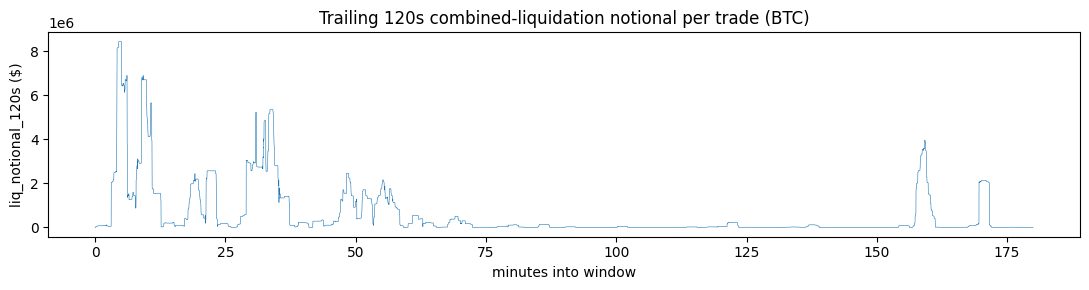

In [8]:
ts = matrix["timestamp"].to_numpy()
y = matrix["liq_notional_120s"].to_numpy()
plt.figure(figsize=(11, 3))
plt.plot((ts - ts[0]) / 1e6 / 60, y, lw=0.4)
plt.xlabel("minutes into window"); plt.ylabel("liq_notional_120s ($)")
plt.title("Trailing 120s combined-liquidation notional per trade (BTC)")
plt.tight_layout(); plt.show()

## 7. Full-data generation (streaming)

The trades table has hundreds of millions of rows, so the full feature matrix does not fit in
RAM. `FeatureSet.generate_streaming` prepares the liquidation/BBO streams once and reads the
trades parquet in batches, writing each batch's features to disk so memory stays bounded:

```python
fs.generate_streaming(
    trades_path=loader.trades_path("btc", data_root=DATA_ROOT),
    bbo=frames["bbo"], liq_binance=frames["liq_binance"], liq_bybit=frames["liq_bybit"],
    batch_rows=20_000_000, out_path="features_btc.parquet",
)
```

## Summary

| Component | File |
|---|---|
| Feature interface (`calculate`) | `shaw_features/base.py` |
| Polars boundary, +200 ms lag, prefix sums, BBO | `shaw_features/context.py` |
| Causal window primitives `[t-W, t)` | `shaw_features/windows.py` |
| 12 example features | `shaw_features/features.py` |
| Validators (NaN/inf, alignment, no-lookahead) | `shaw_features/validation.py` |
| Generation pipeline + streaming | `shaw_features/pipeline.py` |
| Data loading / sampling | `shaw_features/loader.py` |
| Unit tests | `tests/` (run `pytest`) |

All 12 example features pass every validator on real data; the differential check rejects a
feature that reads the future.